Solar Data  - Benin
    EDA

Step 1 :  Importing essential Libraries

In [2]:
# Importing essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats  import zscore

Step 2 : Import & load the Data into a Pandas Data Frame

In [3]:
# Imprting the file & loading it to a pandas Data Frame
path = "../data/benin-malanville.csv"
df=pd.read_csv(path)

Sept 3 : Examine the Data

In [4]:
# Exploring the Data Set
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


Step 4 : Check For Missing Values

In [5]:
# Checking for Missing Values-1
df.isna().any()

Timestamp        False
GHI              False
DNI              False
DHI              False
ModA             False
ModB             False
Tamb             False
RH               False
WS               False
WSgust           False
WSstdev          False
WD               False
WDstdev          False
BP               False
Cleaning         False
Precipitation    False
TModA            False
TModB            False
Comments          True
dtype: bool

In [6]:
# Checking for Missing Values-2
df.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

Step 5 : Check For Outliers Using Various Mechanisms

In [7]:
# Checking for Outliers DNI

Q1_GHI = df['GHI'].quantile(0.25)
Q3_GHI = df['GHI'].quantile(0.75)

IQR_GHI = Q3_GHI -Q1_GHI

Lower_Bound_GHI = Q1_GHI - 1.5 * IQR_GHI
Upper_Bound_GHI = Q3_GHI + 1.5 * IQR_GHI

GHI_Outliers = df[(df['GHI']<Lower_Bound_GHI) | (df['GHI']> Upper_Bound_GHI) ]

GHI_Outliers


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
671,2021-08-09 11:12,1274.0,698.8,615.2,1210.3,1210.3,30.1,69.6,3.4,4.1,0.6,175.8,13.3,999,0,0.0,63.7,53.1,NaN
674,2021-08-09 11:15,1349.0,771.8,618.0,1281.5,1281.5,30.9,67.1,4.0,4.6,0.4,169.1,12.3,999,0,0.0,65.0,53.5,NaN
676,2021-08-09 11:17,1334.0,751.9,620.0,1267.3,1267.3,31.1,67.0,2.7,3.6,0.6,208.0,15.9,999,0,0.0,66.0,53.9,NaN
849,2021-08-09 14:10,1253.0,714.8,552.5,1156.0,1155.0,31.0,64.2,3.3,3.9,0.5,241.2,7.9,997,0,0.0,57.6,52.1,NaN
850,2021-08-09 14:11,1324.0,813.0,532.3,1218.0,1217.0,31.0,62.9,2.2,3.1,0.6,225.6,10.7,997,0,0.0,58.7,53.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522046,2022-08-06 12:47,1218.0,619.7,580.5,1130.0,1128.0,30.3,70.7,3.5,4.4,0.6,266.2,13.5,996,0,0.0,55.1,48.2,NaN
522067,2022-08-06 13:08,1218.0,724.9,477.8,1137.0,1133.0,30.5,67.3,4.3,5.6,1.1,258.9,10.3,996,0,0.0,53.9,47.5,NaN
522073,2022-08-06 13:14,1218.0,759.1,446.2,1120.0,1112.0,30.9,66.3,4.3,5.1,0.6,297.6,9.8,996,0,0.0,61.6,53.1,NaN
522074,2022-08-06 13:15,1262.0,772.4,475.8,1166.0,1153.0,31.1,66.0,3.4,4.6,0.7,288.7,14.6,996,0,0.0,62.1,53.1,NaN


In [8]:
# Checking for Outliers DHI

Q1_DHI = df['DHI'].quantile(0.25)
Q3_DHI = df['DHI'].quantile(0.75)

IQR_DHI = Q3_DHI -Q1_DHI

Lower_Bound_DHI = Q1_DHI - 1.5 * IQR_DHI
Upper_Bound_DHI = Q3_DHI + 1.5 * IQR_DHI

DHI_Outliers = df[(df['DHI']<Lower_Bound_DHI) | (df['DHI']> Upper_Bound_DHI) ]

DHI_Outliers

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
668,2021-08-09 11:09,843.0,304.1,554.9,790.5,796.6,30.2,69.1,2.3,3.6,0.8,171.3,25.8,999,0,0.0,62.2,52.1,NaN
669,2021-08-09 11:10,776.4,201.1,583.3,740.4,745.0,30.2,69.0,2.8,3.6,0.6,171.8,20.1,999,0,0.0,62.6,52.6,NaN
670,2021-08-09 11:11,836.0,235.0,610.6,778.8,783.8,30.3,68.2,3.2,4.1,0.7,190.5,18.4,999,0,0.0,63.0,52.7,NaN
671,2021-08-09 11:12,1274.0,698.8,615.2,1210.3,1210.3,30.1,69.6,3.4,4.1,0.6,175.8,13.3,999,0,0.0,63.7,53.1,NaN
672,2021-08-09 11:13,938.0,340.1,612.8,891.1,891.1,30.4,68.4,3.4,4.6,0.9,171.5,11.9,999,0,0.0,65.8,54.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524921,2022-08-08 12:42,723.9,161.8,554.7,678.7,676.7,30.7,70.9,5.2,7.2,0.7,214.1,9.9,995,0,0.0,57.7,49.2,NaN
524937,2022-08-08 12:58,687.3,134.5,546.3,644.8,642.2,30.3,72.7,4.3,5.4,0.8,230.1,14.0,994,0,0.0,51.7,45.3,NaN
524938,2022-08-08 12:59,680.5,129.4,544.3,643.6,640.7,30.3,73.4,4.4,5.1,0.5,237.2,9.1,994,0,0.0,52.0,45.3,NaN
524964,2022-08-08 13:25,683.3,131.4,545.4,644.2,636.0,30.8,69.7,4.6,5.4,0.7,230.0,7.1,994,0,0.0,53.5,45.6,NaN


In [9]:
# Checking for Outliers DHI

Q1_DHI = df['DHI'].quantile(0.25)
Q3_DHI = df['DHI'].quantile(0.75)

IQR_DHI = Q3_DHI -Q1_DHI

Lower_Bound_DHI = Q1_DHI - 1.5 * IQR_DHI
Upper_Bound_DHI = Q3_DHI + 1.5 * IQR_DHI

DHI_Outliers = df[(df['DHI']<Lower_Bound_DHI) | (df['DHI']> Upper_Bound_DHI) ]

DHI_Outliers

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
668,2021-08-09 11:09,843.0,304.1,554.9,790.5,796.6,30.2,69.1,2.3,3.6,0.8,171.3,25.8,999,0,0.0,62.2,52.1,NaN
669,2021-08-09 11:10,776.4,201.1,583.3,740.4,745.0,30.2,69.0,2.8,3.6,0.6,171.8,20.1,999,0,0.0,62.6,52.6,NaN
670,2021-08-09 11:11,836.0,235.0,610.6,778.8,783.8,30.3,68.2,3.2,4.1,0.7,190.5,18.4,999,0,0.0,63.0,52.7,NaN
671,2021-08-09 11:12,1274.0,698.8,615.2,1210.3,1210.3,30.1,69.6,3.4,4.1,0.6,175.8,13.3,999,0,0.0,63.7,53.1,NaN
672,2021-08-09 11:13,938.0,340.1,612.8,891.1,891.1,30.4,68.4,3.4,4.6,0.9,171.5,11.9,999,0,0.0,65.8,54.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524921,2022-08-08 12:42,723.9,161.8,554.7,678.7,676.7,30.7,70.9,5.2,7.2,0.7,214.1,9.9,995,0,0.0,57.7,49.2,NaN
524937,2022-08-08 12:58,687.3,134.5,546.3,644.8,642.2,30.3,72.7,4.3,5.4,0.8,230.1,14.0,994,0,0.0,51.7,45.3,NaN
524938,2022-08-08 12:59,680.5,129.4,544.3,643.6,640.7,30.3,73.4,4.4,5.1,0.5,237.2,9.1,994,0,0.0,52.0,45.3,NaN
524964,2022-08-08 13:25,683.3,131.4,545.4,644.2,636.0,30.8,69.7,4.6,5.4,0.7,230.0,7.1,994,0,0.0,53.5,45.6,NaN


Step 6 : Compute Z Scores to Determine Outliers

In [10]:
# Compute Z-Scores across numerical columns to check for Outliers
cols_to_chk = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
zscore_scipy = np.abs(df[cols_to_chk].apply(zscore))
zscore_scipy

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,0.730102,0.639591,0.733873,0.723749,0.723088,1.322831,1.187312
1,0.729800,0.639591,0.733873,0.723749,0.723088,1.322831,1.384442
2,0.729800,0.639591,0.733873,0.723749,0.723088,1.135736,0.842334
3,0.729800,0.639209,0.733243,0.723749,0.723088,1.198101,1.039464
4,0.729498,0.639209,0.733243,0.723749,0.723088,1.260466,1.039464
...,...,...,...,...,...,...,...
525595,0.743088,0.639209,0.764120,0.723749,0.723088,1.135736,0.842334
525596,0.743088,0.639209,0.763490,0.723749,0.723088,1.198101,1.039464
525597,0.743088,0.639209,0.763490,0.723749,0.723088,0.948641,0.842334
525598,0.743088,0.639209,0.763490,0.723749,0.723088,0.761547,0.743769


In [11]:
outliers=(zscore_scipy > 3).any(axis=1)
df['Cleaning_Flag']=outliers
oultier_rows=df[df['Cleaning_Flag']]
print(df['Cleaning_Flag'].value_counts())
oultier_rows.head()

Cleaning_Flag
False    517860
True       7740
Name: count, dtype: int64


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Cleaning_Flag
670,2021-08-09 11:11,836.0,235.0,610.6,778.8,783.8,30.3,68.2,3.2,4.1,0.7,190.5,18.4,999,0,0.0,63.0,52.7,NaN,True
671,2021-08-09 11:12,1274.0,698.8,615.2,1210.3,1210.3,30.1,69.6,3.4,4.1,0.6,175.8,13.3,999,0,0.0,63.7,53.1,NaN,True
672,2021-08-09 11:13,938.0,340.1,612.8,891.1,891.1,30.4,68.4,3.4,4.6,0.9,171.5,11.9,999,0,0.0,65.8,54.3,NaN,True
673,2021-08-09 11:14,718.5,126.8,593.2,682.6,682.6,30.6,68.2,4.7,5.6,0.6,160.7,8.0,999,0,0.0,65.4,54.2,NaN,True
674,2021-08-09 11:15,1349.0,771.8,618.0,1281.5,1281.5,30.9,67.1,4.0,4.6,0.4,169.1,12.3,999,0,0.0,65.0,53.5,NaN,True


Step 7 : Separate Outliers & Formulate a New Cleaned Data Frame

In [12]:
df_clean=df.copy()
df_clean[cols_to_chk]=df_clean[cols_to_chk].fillna(df_clean[cols_to_chk].mean())
df_clean.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Cleaning_Flag
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN,False
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN,False
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN,False
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN,False
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN,False


Setp 8 : Export the Cleaned Data Frame to CSV

In [13]:
df_clean.to_csv('../data/clean/benin_clean.csv',index=False)

Step 9 : Carryput Time Series Analyis to selected Parameters

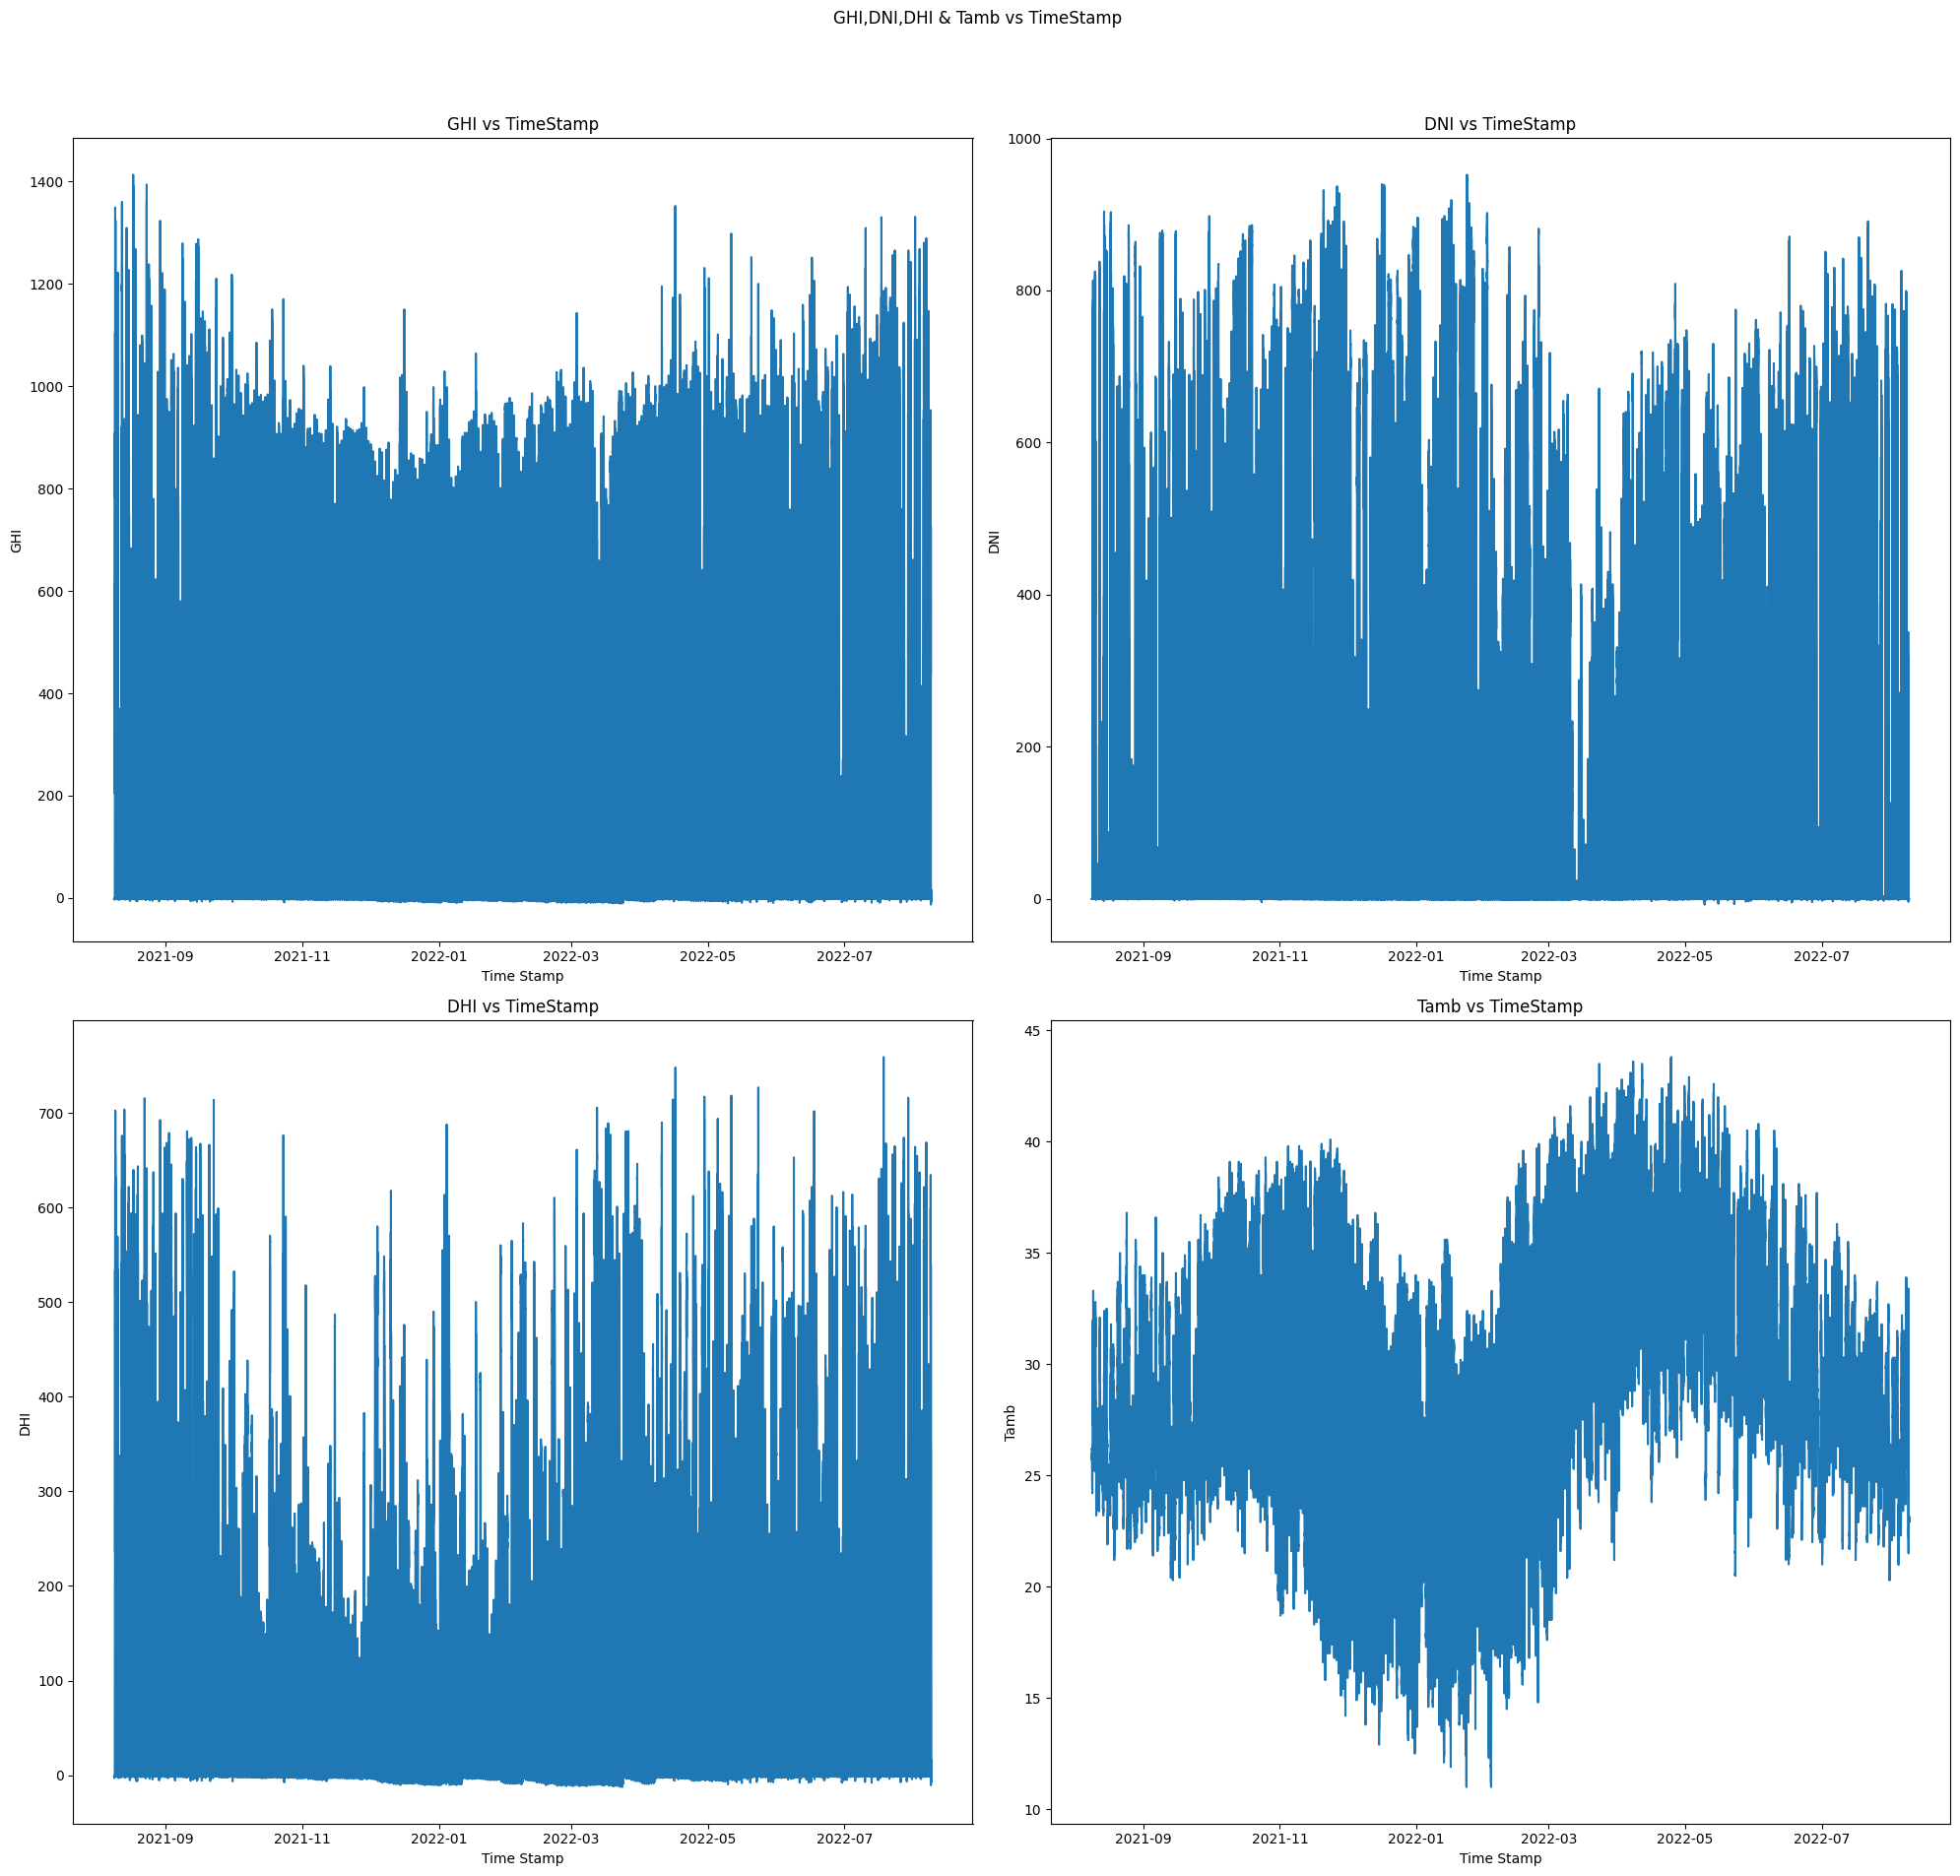

In [16]:
# Change over Time
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors='coerce')

fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(20,20))

axes[0,0].plot(df_clean['Timestamp'], df_clean['GHI'])
axes[0,0].set_xlabel('Time Stamp')
axes[0,0].set_ylabel('GHI')
axes[0,0].set_title('GHI vs TimeStamp')

axes[0,1].plot(df_clean['Timestamp'], df_clean['DNI'])
axes[0,1].set_xlabel('Time Stamp')
axes[0,1].set_ylabel('DNI')
axes[0,1].set_title('DNI vs TimeStamp')

axes[1,0].plot(df_clean['Timestamp'], df_clean['DHI'])
axes[1,0].set_xlabel('Time Stamp')
axes[1,0].set_ylabel('DHI')
axes[1,0].set_title('DHI vs TimeStamp')

axes[1,1].plot(df_clean['Timestamp'], df_clean['Tamb'])
axes[1,1].set_xlabel('Time Stamp')
axes[1,1].set_ylabel('Tamb')
axes[1,1].set_title('Tamb vs TimeStamp')

fig.suptitle ('GHI,DNI,DHI & Tamb vs TimeStamp ')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Step 10 : Analyze the Cleaning Effect on the Innitial Data 

<Axes: title={'center': 'Cleanining Impact on Moda & ModB'}, xlabel='Cleaning_Flag'>

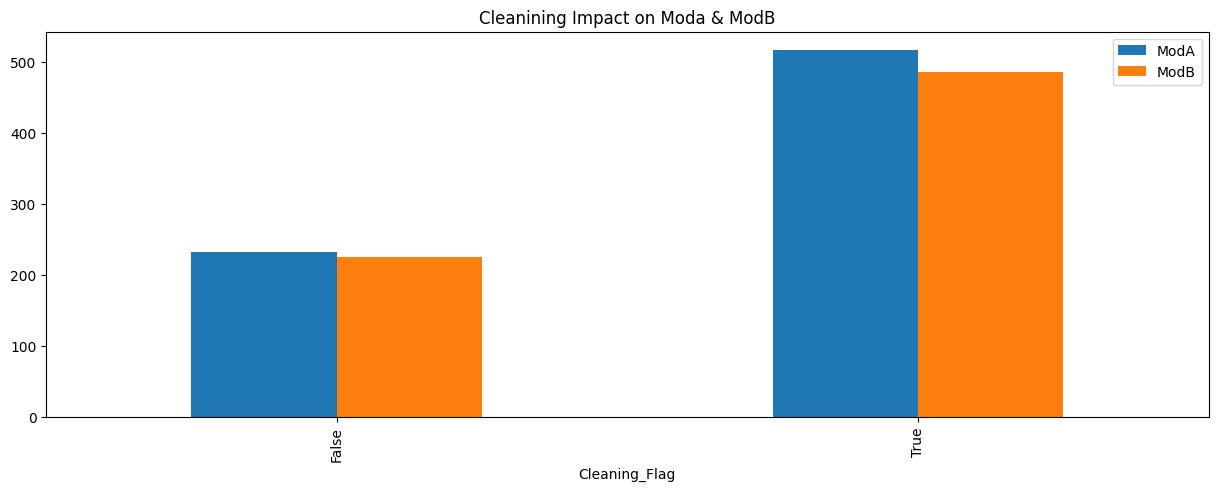

In [13]:
#Cleaning Effect
df.groupby('Cleaning_Flag')[['ModA','ModB']].mean().plot(kind='bar',title='Cleanining Impact on Moda & ModB',figsize=(15,5))

Step 11 : Identify Correlations

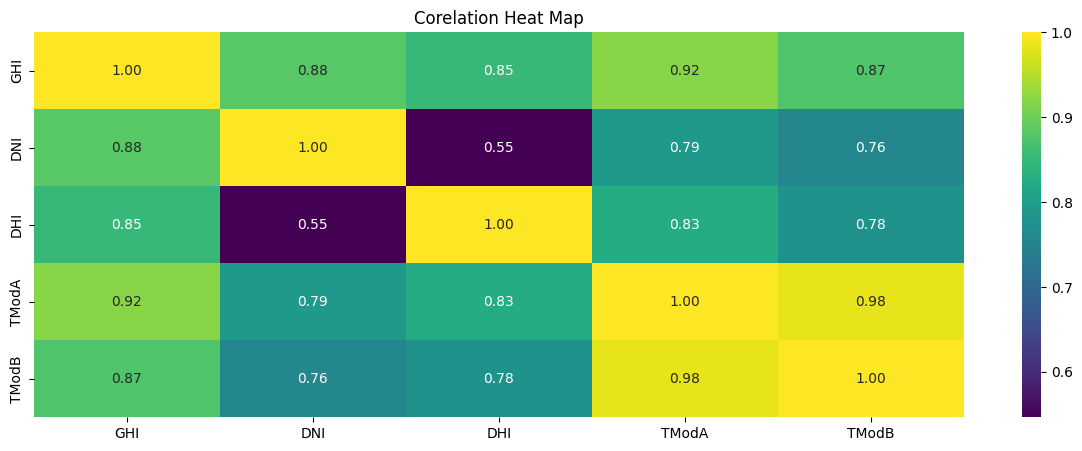

In [17]:
# Correlation through Heat Map
corr = df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
plt.figure(figsize=(15,5))
plt.title('Corelation Heat Map')
sns.heatmap(corr,annot=True,fmt ='.2f',cmap='viridis')
plt.show()

Step 12 : Plot Scratter Plots 

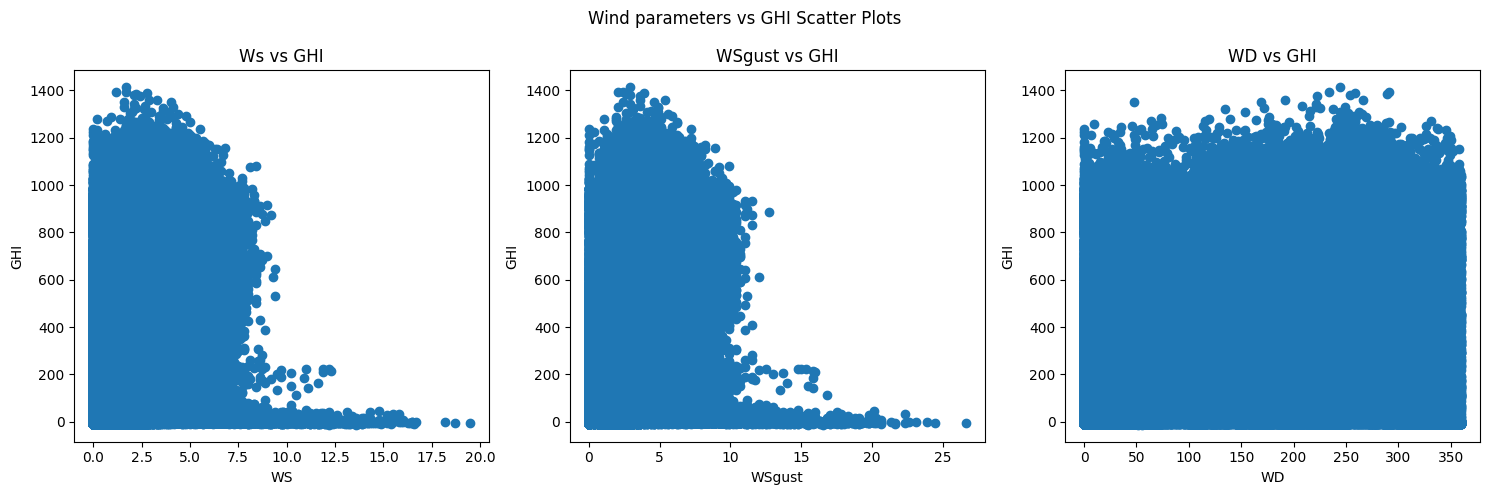

In [18]:
#Scatter Plots

fig,axes =plt.subplots(nrows=1,ncols=3,figsize=(15,5))

axes[0].scatter(df_clean['WS'],df_clean['GHI'])
axes[0].set_xlabel('WS')
axes[0].set_ylabel('GHI')
axes[0].set_title('Ws vs GHI')

axes[1].scatter(df_clean['WSgust'],df_clean['GHI'])
axes[1].set_xlabel('WSgust')
axes[1].set_ylabel('GHI')
axes[1].set_title('WSgust vs GHI')

axes[2].scatter(df_clean['WD'],df_clean['GHI'])
axes[2].set_xlabel('WD')
axes[2].set_ylabel('GHI')
axes[2].set_title('WD vs GHI')

fig.suptitle('Wind parameters vs GHI Scatter Plots')
plt.tight_layout()
plt.show()

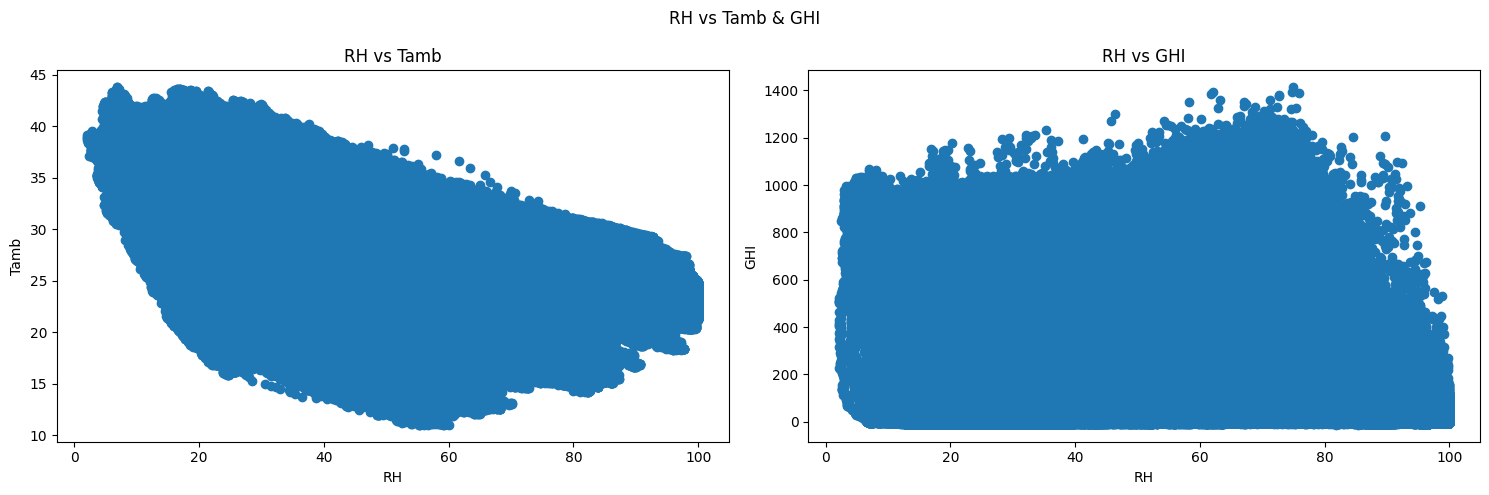

In [19]:
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axes[0].scatter(df_clean['RH'],df_clean['Tamb'])
axes[0].set_xlabel('RH')
axes[0].set_ylabel('Tamb')
axes[0].set_title ('RH vs Tamb')

axes[1].scatter(df_clean['RH'],df_clean['GHI'])
axes[1].set_xlabel('RH')
axes[1].set_ylabel('GHI')
axes[1].set_title ('RH vs GHI')

plt.suptitle('RH vs Tamb & GHI')
plt.tight_layout()
plt.show()

Step 13 : Plot Wind rose (Radial) Graph

C:\Users\henokt\AppData\Local\Temp\ipykernel_32784\3529328803.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


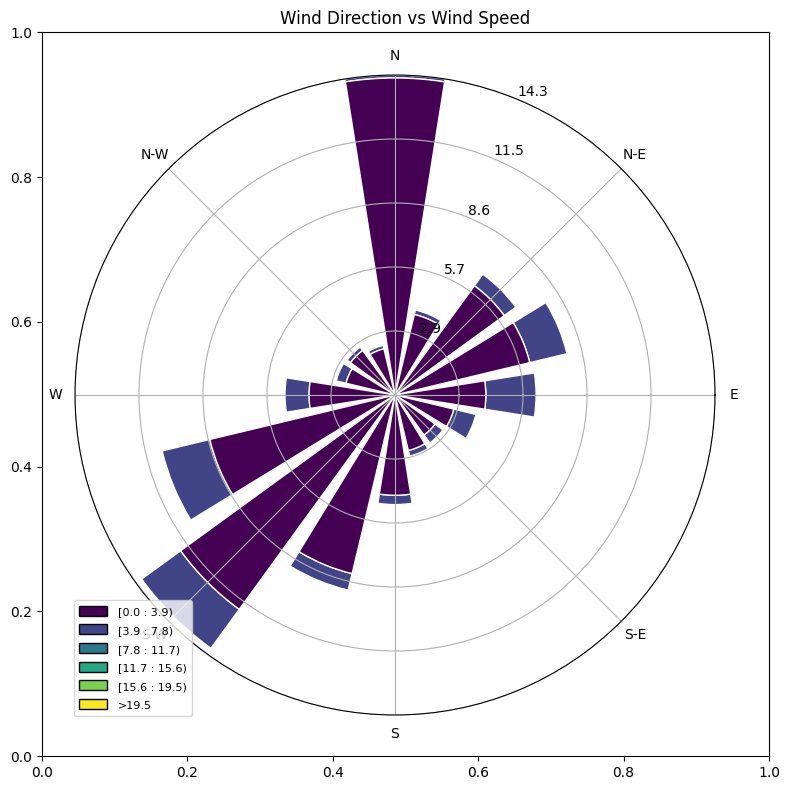

In [20]:
#Widnd Direction vs Wind Speed
from windrose import WindroseAxes

fig = plt.figure(figsize=(8, 8))
plt.title('Wind Direction vs Wind Speed')
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(df_clean['WD'],df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.tight_layout()
plt.show()

Step 14 : Plot a Histogram Plot

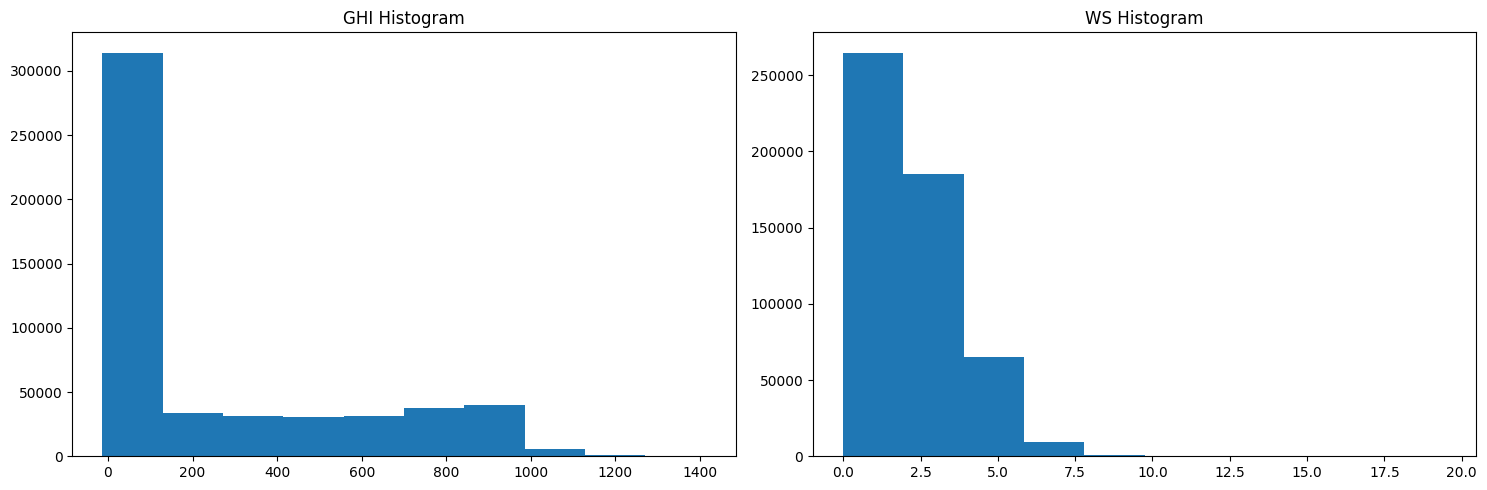

In [21]:
#Histogram plot
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axes[0].hist(df_clean['GHI'])
axes[0].set_title('GHI Histogram')

axes[1].hist(df_clean['WS'])
axes[1].set_title('WS Histogram')

plt.tight_layout()
plt.show()

Step 15 : Plot a Line Graph to analyze Impact of RH on Temprature Readings

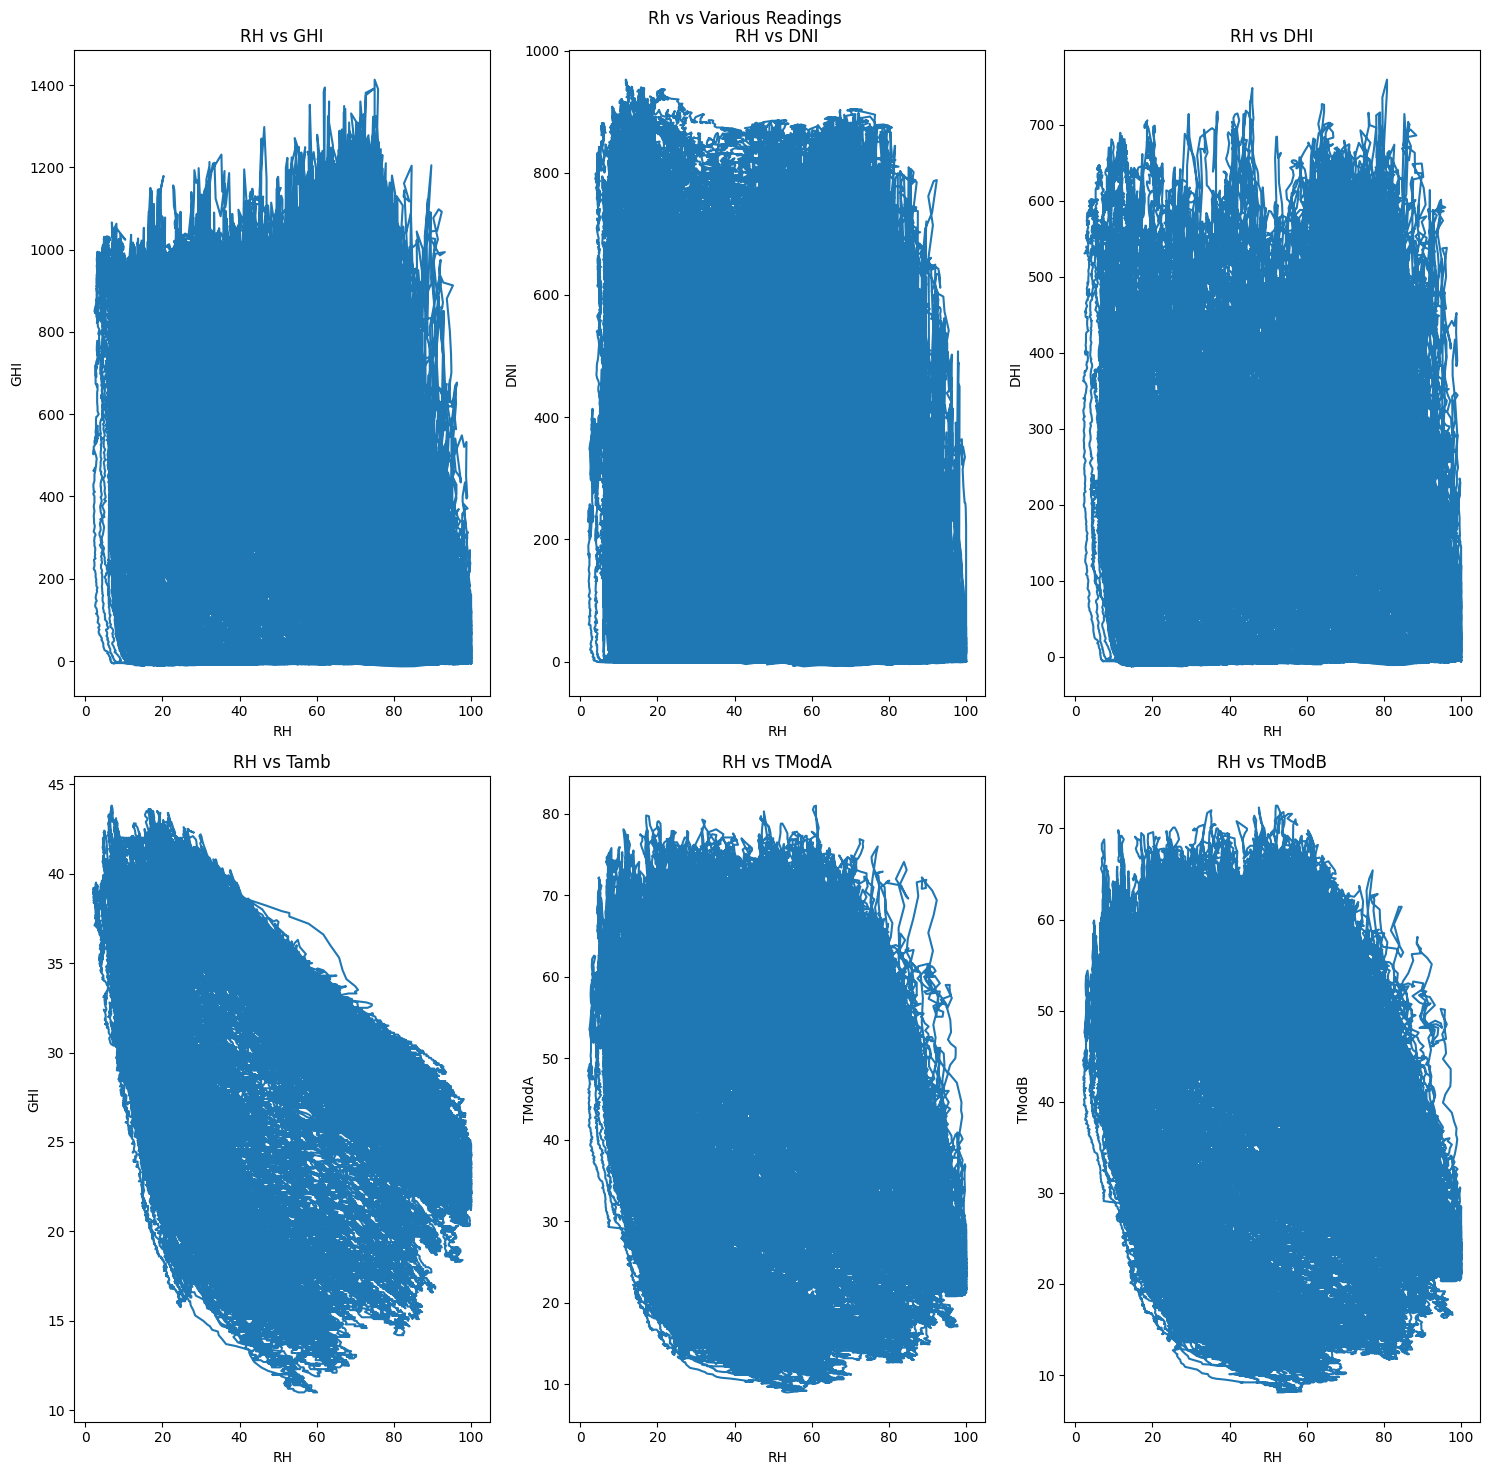

In [22]:
fix,axes =plt.subplots(nrows=2,ncols=3,figsize=(15,15))

axes[0,0].plot(df_clean['RH'],df_clean['GHI'])
axes[0,0].set_xlabel('RH')
axes[0,0].set_ylabel('GHI')
axes[0,0].set_title('RH vs GHI')

axes[0,1].plot(df_clean['RH'],df_clean['DNI'])
axes[0,1].set_xlabel('RH')
axes[0,1].set_ylabel('DNI')
axes[0,1].set_title('RH vs DNI')

axes[0,2].plot(df_clean['RH'],df_clean['DHI'])
axes[0,2].set_xlabel('RH')
axes[0,2].set_ylabel('DHI')
axes[0,2].set_title('RH vs DHI')

axes[1,0].plot(df_clean['RH'],df_clean['Tamb'])
axes[1,0].set_xlabel('RH')
axes[1,0].set_ylabel('GHI')
axes[1,0].set_title('RH vs Tamb')

axes[1,1].plot(df_clean['RH'],df_clean['TModA'])
axes[1,1].set_xlabel('RH')
axes[1,1].set_ylabel('TModA')
axes[1,1].set_title('RH vs TModA')

axes[1,2].plot(df_clean['RH'],df_clean['TModB'])
axes[1,2].set_xlabel('RH')
axes[1,2].set_ylabel('TModB')
axes[1,2].set_title('RH vs TModB')


plt.suptitle('Rh vs Various Readings')
plt.tight_layout()
plt.show()

Step 16 : Plot a Bubble Chart (Scatter Plot) GHI vs. Tamb with bubble size = RH or BP.

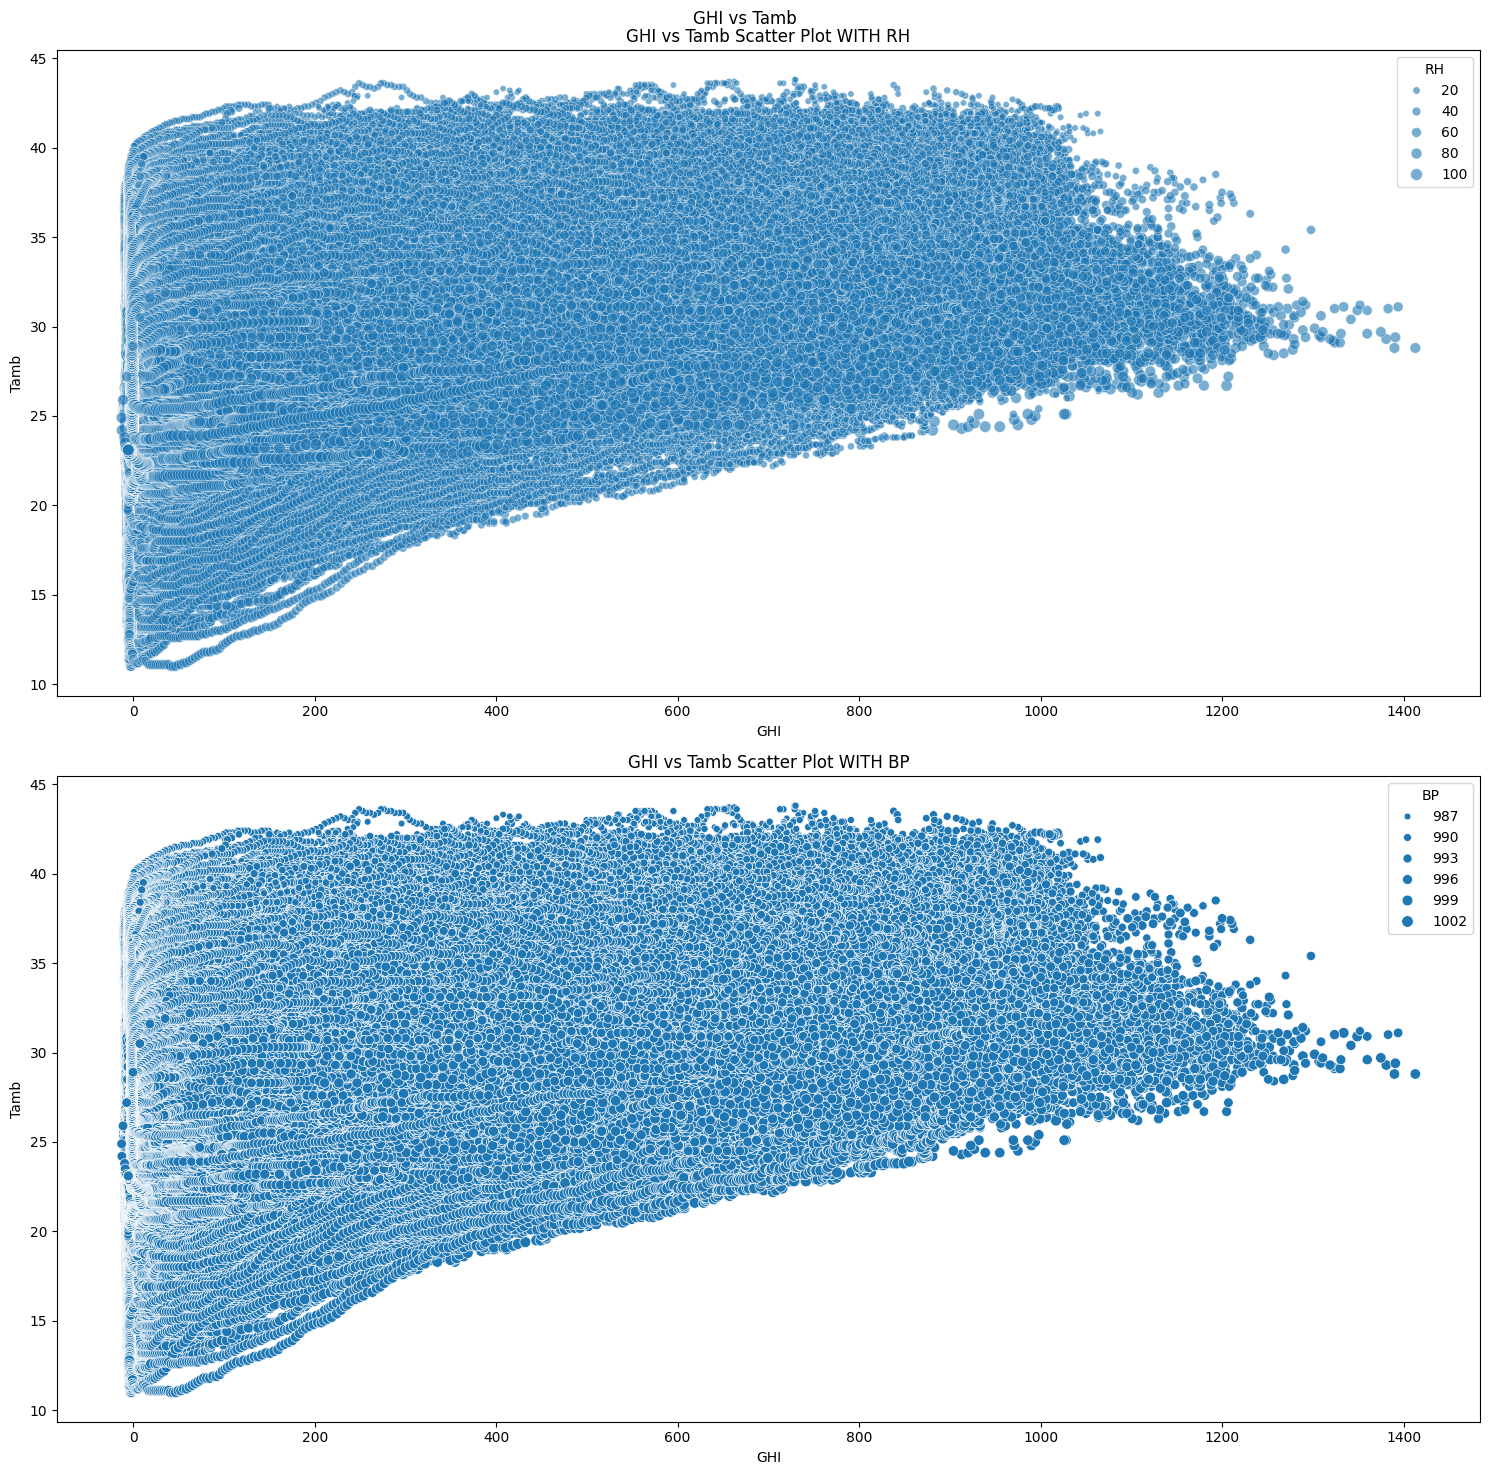

In [23]:
fig,axes=plt.subplots(nrows=2,ncols=1,figsize=(15,15))

sns.scatterplot(x='GHI',y='Tamb',data=df_clean,size='RH',ax=axes[0],alpha=0.6)
axes[0].set_xlabel('GHI')
axes[0].set_ylabel('Tamb')
axes[0].set_title('GHI vs Tamb Scatter Plot WITH RH')

sns.scatterplot(x='GHI',y='Tamb',data=df_clean,size='BP',ax=axes[1])
axes[1].set_xlabel('GHI')
axes[1].set_ylabel('Tamb')
axes[1].set_title('GHI vs Tamb Scatter Plot WITH BP')

plt.suptitle('GHI vs Tamb')

plt.tight_layout()
plt.show()